In [ ]:
import os
os.environ['TORCHANI_NO_WARN_EXTENSIONS'] = '1'

import torch
import torch.nn as nn
import torch.optim as optim
import torchani
from torchani.nn._core import AtomicNetwork
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from torch_geometric.datasets import MD17

In [ ]:
#params
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

MOLECULE_NAME = 'aspirin'
N_TRAIN = 1000
N_VAL = 1000
BATCH_SIZE = 32
N_REPEATS = 5
MAX_EPOCHS = 200
PATIENCE = 20

GRID_PARAMS = [
    (1.0, 1.0),
    (1.0, 10.0),
    (1.0, 50.0),
    (1.0, 100.0),
    (1.0, 150.0),
    (1.0, 300.0),
    (1.0, 500.0),
]
CSV_GRID_FILENAME = f'grid_search_alpha_beta_{N_REPEATS}reps.csv'


In [ ]:
#class
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0

def make_ani_networks():
    return torchani.nn.ANINetworks({
        'H': AtomicNetwork(layer_dims=(384, 160, 128, 96, 1), activation="celu", bias=True),
        'C': AtomicNetwork(layer_dims=(384, 144, 112, 96, 1), activation="celu", bias=True),
        'N': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
        'O': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
    })

class TorchANI2Model(nn.Module):
    def __init__(self, converter, aev_comp, nns):
        super().__init__()
        self.converter = converter
        self.aev_comp  = aev_comp
        self.nns       = nns

    def forward(self, atomic_numbers, coords):
        species_idx = self.converter(atomic_numbers)
        aevs = self.aev_comp(species_idx, coords)
        return self.nns(species_idx, aevs)

In [ ]:
#data
print(f"Chargement de MD17 ({MOLECULE_NAME}) sur {DEVICE}")
dataset = MD17(root='./data/MD17', name=MOLECULE_NAME)

# Chargement unique de species_converter et aev_computer
_ref = torchani.models.ANI1x(periodic_table_index=True).to(DEVICE)
species_converter = _ref.species_converter
aev_computer      = _ref.aev_computer
del _ref

z_raw = dataset[0].z.unsqueeze(0).to(DEVICE)
species_base = z_raw.clone()

R_full = torch.stack([data.pos for data in dataset]).to(DEVICE)
E_full = torch.stack([data.energy for data in dataset]).to(DEVICE)
F_full = torch.stack([data.force for data in dataset]).to(DEVICE)

# Graine fixe pour les indices val/train pour des comparaisons reproductibles
indices = torch.randperm(len(R_full), generator=torch.Generator().manual_seed(42))
val_idx = indices[-N_VAL:]
train_pool_idx = indices[:-N_VAL]

species_val = species_base.repeat(N_VAL, 1)
R_val, E_val, F_val = R_full[val_idx], E_full[val_idx], F_full[val_idx]

In [ ]:
#Boucle d'entrainement
results  = []
mse_loss = nn.MSELoss()

print(f"\n🚀 Démarrage du Grid Search ({len(GRID_PARAMS) * N_REPEATS} entraînements)")

for alpha, beta in GRID_PARAMS:
    print(f"\n{'='*40}\n▶️  Alpha={alpha} | Beta={beta}\n{'='*40}")

    for rep in tqdm(range(N_REPEATS), desc=f"Répétitions (β={beta})"):

        # Graine fixe par répétition pour reproductibilité inter-configurations
        rep_gen = torch.Generator().manual_seed(rep)

        # Nom de fichier sans '.' pour éviter les ambiguïtés
        beta_tag = str(int(beta)) if beta == int(beta) else str(beta).replace('.', 'p')
        ckpt_path = f"ckpt_b{beta_tag}_r{rep}.pt"

        rep_indices = torch.randperm(len(train_pool_idx), generator=rep_gen)[:N_TRAIN]
        current_train_idx = train_pool_idx[rep_indices]

        species_tr = species_base.repeat(N_TRAIN, 1)
        R_tr, E_tr, F_tr = R_full[current_train_idx], E_full[current_train_idx], F_full[current_train_idx]

        # Centrage puriste calculé dynamiquement
        E_mean = E_tr.mean()
        E_tr_centered = E_tr  - E_mean
        E_val_centered = E_val - E_mean

        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(species_tr, R_tr, E_tr_centered, F_tr),
            batch_size=BATCH_SIZE, shuffle=True
        )
        val_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(species_val, R_val, E_val_centered, F_val),
            batch_size=BATCH_SIZE, shuffle=False
        )

        model = TorchANI2Model(species_converter, aev_computer, make_ani_networks()).to(DEVICE)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, threshold=1e-4)
        early_stopping = EarlyStopping(patience=PATIENCE, min_delta=1e-4, path=ckpt_path)

        try:
            #train
            for epoch in range(MAX_EPOCHS):
                model.train()
                for batch_species, batch_R, batch_E, batch_F in train_loader:
                    optimizer.zero_grad(set_to_none=True)
                    batch_R.requires_grad_(True)

                    preds_E = model(batch_species, batch_R)
                    preds_F = -torch.autograd.grad(preds_E.sum(), batch_R, create_graph=True, retain_graph=True)[0]

                    loss = (alpha * mse_loss(preds_E.flatten(), batch_E.flatten()) +
                            beta  * mse_loss(preds_F.flatten(), batch_F.flatten()))
                    loss.backward()
                    optimizer.step()

                #val
                model.eval()
                epoch_val_loss = 0.0
                with torch.set_grad_enabled(True):
                    for v_s, v_R, v_E, v_F in val_loader:
                        v_R_req = v_R.clone().detach().requires_grad_(True)
                        v_preds_E = model(v_s, v_R_req)
                        v_preds_F = -torch.autograd.grad(v_preds_E.sum(), v_R_req, create_graph=False)[0]
                        epoch_val_loss += (
                            alpha * mse_loss(v_preds_E.flatten(), v_E.flatten()) +
                            beta  * mse_loss(v_preds_F.flatten(), v_F.flatten())
                        ).item()

                epoch_val_loss /= len(val_loader)
                scheduler.step(epoch_val_loss)
                early_stopping(epoch_val_loss, model)
                if early_stopping.early_stop:
                    break

            #best model load
            model.load_state_dict(torch.load(ckpt_path, weights_only=True))

            #test
            model.eval()
            total_mae_E = total_mae_F = total_E_items = total_F_items = 0
            with torch.set_grad_enabled(True):
                for b_species, b_R, b_E, b_F in val_loader:
                    b_R_req = b_R.clone().detach().requires_grad_(True)
                    b_preds_E = model(b_species, b_R_req)
                    b_pred_forces = -torch.autograd.grad(b_preds_E.sum(), b_R_req, create_graph=False)[0]

                    total_mae_E += torch.abs(b_preds_E.flatten() - b_E.flatten()).sum().item()
                    total_mae_F += torch.abs(b_pred_forces - b_F).sum().item()
                    total_E_items += b_E.numel()
                    total_F_items += b_F.numel()

            results.append({
                "Alpha":      alpha,
                "Beta":       beta,
                "Repetition": rep + 1,
                "MAE_Energy": total_mae_E / total_E_items,
                "MAE_Force":  total_mae_F / total_F_items,
            })

        finally:
            if os.path.exists(ckpt_path):
                os.remove(ckpt_path)

        #Mise à jour du fichier CSV après chaque répétition
        pd.DataFrame(results).to_csv(CSV_GRID_FILENAME, index=False)

📥 Chargement de MD17 (aspirin) sur cpu...

🚀 Démarrage du Grid Search (35 entraînements)

▶️  Alpha=1.0 | Beta=1.0


📥 Chargement de MD17 (aspirin) sur cpu...

🚀 Démarrage du Grid Search (35 entraînements)

▶️  Alpha=1.0 | Beta=1.0


Répétitions (β=1.0):   0%|          | 0/5 [00:00<?, ?it/s]

📥 Chargement de MD17 (aspirin) sur cpu...

🚀 Démarrage du Grid Search (35 entraînements)

▶️  Alpha=1.0 | Beta=1.0


Répétitions (β=1.0):   0%|          | 0/5 [00:00<?, ?it/s]

...


▶️  Alpha=1.0 | Beta=300.0


Répétitions (β=300.0):   0%|          | 0/5 [00:00<?, ?it/s]


▶️  Alpha=1.0 | Beta=500.0


Répétitions (β=500.0):   0%|          | 0/5 [00:00<?, ?it/s]


🏆 BILAN MOYEN DU GRID SEARCH :
   Alpha   Beta  MAE_Energy  MAE_Force
0    1.0    1.0    0.756436   1.991738
1    1.0   10.0    0.598500   1.243975
2    1.0   50.0    0.624886   1.022167
3    1.0  100.0    0.550936   0.994405
4    1.0  150.0    0.819944   0.987622
5    1.0  300.0    0.541924   0.974030
6    1.0  500.0    0.766237   0.978657


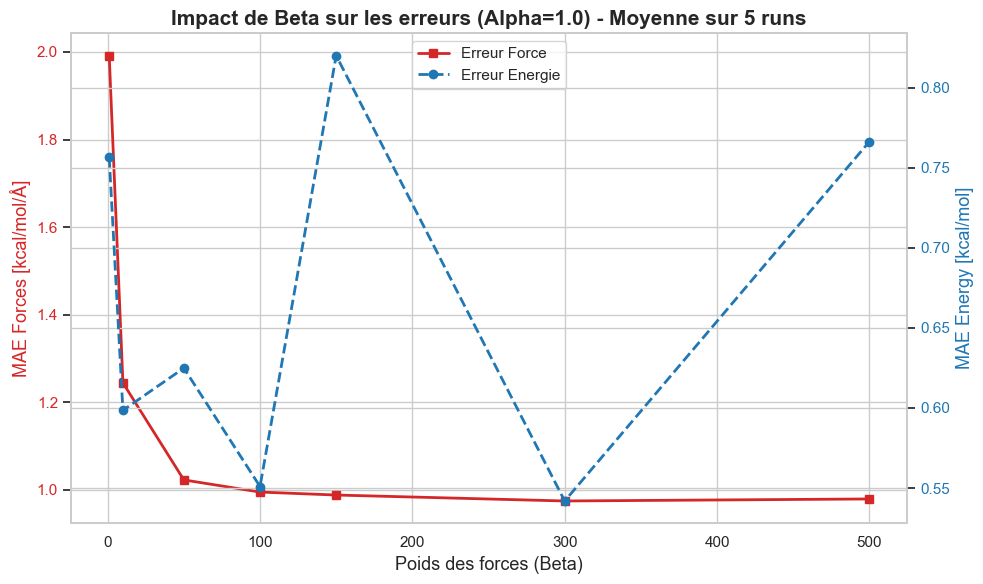

In [ ]:
#resultats et graph
df_res = pd.DataFrame(results)

df_mean = df_res.groupby(['Alpha', 'Beta']).mean().reset_index()
print("\nBILAN MOYEN DU GRID SEARCH :")
print(df_mean[['Alpha', 'Beta', 'MAE_Energy', 'MAE_Force']].sort_values(by='Beta'))

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))
df_plot = df_mean[df_mean['Alpha'] == 1.0].sort_values('Beta')

color = 'tab:red'
ax1.set_xlabel('Poids des forces (Beta)', fontsize=13)
ax1.set_ylabel('MAE Forces [kcal/mol/Å]', color=color, fontsize=13)
ax1.plot(df_plot['Beta'], df_plot['MAE_Force'], marker='s', color=color, linewidth=2, label="Erreur Force")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('MAE Energy [kcal/mol]', color=color, fontsize=13)
ax2.plot(df_plot['Beta'], df_plot['MAE_Energy'], marker='o', color=color, linewidth=2, linestyle='--', label="Erreur Energie")
ax2.tick_params(axis='y', labelcolor=color)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title("Impact de Beta sur les erreurs (Alpha=1.0) - Moyenne sur 5 runs", fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()
